# Lacunae Analysis Workflow for microCT

- By: Danielle Whittier and ORMIR microCT contributors, July 2026
- Code license: MIT license, as distributed with the `lacunae-analysis` repository
- Notebook purpose: guide a single-scan lacunae analysis workflow for high-resolution microCT images

This notebook demonstrates the package workflow for reading AIM files, converting voxel values to density, selecting a threshold from an annotated histogram, segmenting lacunae, and saving reproducible analysis outputs.

---
## Aims

This notebook is a guide for running lacunae analysis on 1.2 µm microCT scans.

By the end of the notebook, you will have:

1. Loaded a `.aim` scan with `aimio-py` through the shared `lacunae_analysis` package.
2. Converted the scan into density values before thresholding.
3. Reviewed an annotated threshold histogram with Otsu, peak-based, and optional manual thresholds.
4. Segmented lacunae and inspected the segmentation overlays.
5. Calculated lacuna density metrics and exported reproducible outputs.

### Contents

- [Computational workflow](#workflow)
- [Dependencies](#dependencies)
- [References](#references)
- [Acknowledgements](#acknowledgements)

---
<a name="workflow"></a>
## Computational workflow

The workflow below is organized as a reproducible guide. Narrative cells explain the purpose of each step; code cells expose the parameters that are most likely to be changed between scans.

The package functions are used directly so that the notebook remains lightweight and consistent with the command-line workflow.

### Installation

Before running this notebook, install the repository into the active environment. From the repository root:

```bash
conda activate lacunae-analysis
python -m pip install -e .
```

AIM file support is provided by `aimio-py`, which is listed as a project dependency. If needed, install it explicitly:

```bash
python -m pip install aimio-py
```

### Imports

These imports load the public package API used throughout the notebook. The thresholding import includes a helper that returns both the numeric thresholds and the annotated histogram figure.

In [1]:
%matplotlib inline

from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from lacunae_analysis.io import load_aim_as_density
from lacunae_analysis.metrics import analyze_lacuna_density
from lacunae_analysis.models import DensityFilterSettings, ScanInput, ThresholdSettings
from lacunae_analysis.pipeline import run_single_scan, run_single_scan_job
from lacunae_analysis.segmentation import plot_lacuna_segmentation, segment_lacunae
from lacunae_analysis.thresholding import compute_threshold_with_figure

### Variables and constants

Edit the paths and settings in this cell before running the workflow.

- `scan_path`: AIM file to analyze.
- `output_dir`: folder where diagnostic plots and summary tables will be written.
- `manual_threshold`: set to `0.0` to use the peak-based threshold, or set a density value to override it.
- `bone_sigma` and `lacuna_sigma`: Gaussian smoothing values used during segmentation.

In [2]:
scan_path = Path("/path/to/file/file.aim")
output_dir = Path("/path/to/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

manual_threshold = 0.0
bone_sigma = 10.0
lacuna_sigma = 1.2

density_filter_settings = DensityFilterSettings(
    lower_volume_um3=200.0,
    upper_volume_um3=1500.0,
)

if not scan_path.exists():
    raise FileNotFoundError(
        "Update `scan_path` to point at a local .aim scan before running the workflow."
    )

### 1. Load the AIM scan as density

`load_aim_as_density` reads the AIM file with `aimio-py` and returns a `LoadedScan` object. The voxel array is converted to density before thresholding so the histogram and threshold values are easier to interpret.

In [3]:
loaded_scan = load_aim_as_density(scan_path)

scan_metadata = pd.Series(
    {
        "source_path": loaded_scan.source_path,
        "array_shape_z_y_x": loaded_scan.voxel_data.shape,
        "spacing": loaded_scan.spacing,
        "origin": loaded_scan.origin,
        "units": loaded_scan.units,
        "density_slope": loaded_scan.density_slope,
        "density_intercept": loaded_scan.density_intercept,
    }
)
scan_metadata

source_path          /Users/daniellewhittier/Documents/Research/Lac...
array_shape_z_y_x                                      (500, 901, 879)
spacing              (0.0020000000949949026, 0.0020000000949949026,...
origin                                            (1417.0, 997.0, 0.0)
units                                                              BMD
density_slope                                                 0.090784
density_intercept                                          -197.001007
dtype: object

### 2. Review the threshold histogram

The threshold plot is the key quality-control step. It shows the density histogram with annotations for:

- Otsu threshold
- peak-based threshold
- manual threshold, when one is provided
- smoothed histogram and detected peaks

The selected threshold is the manual threshold when `manual_threshold != 0.0`; otherwise it is the peak-based threshold.

otsu_threshold        7.378937e+02
manual_threshold      0.000000e+00
peak_threshold        1.129246e+03
n_voxels_used         3.959895e+08
selected_threshold    1.129246e+03
dtype: float64

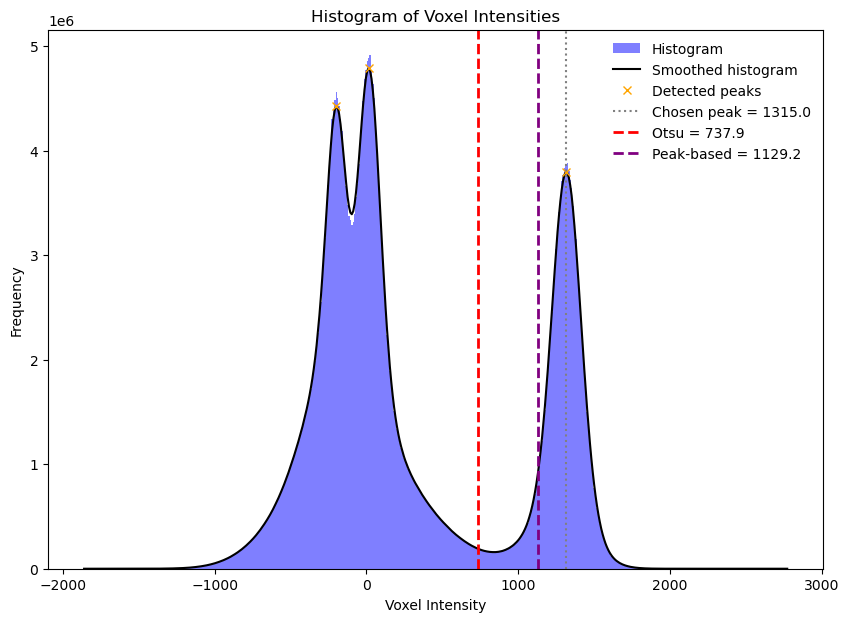

In [4]:
threshold_results, threshold_figure = compute_threshold_with_figure(
    loaded_scan,
    manual_threshold=manual_threshold,
)

pd.Series(threshold_results)

### 3. Segment lacunae

The segmentation step uses the selected density threshold and the smoothing parameters set above. This creates the bone mask and the unfiltered lacuna candidate mask. The final diagnostic plot is shown after volume filtering so it represents the full segmentation workflow.

In [5]:
segmentation_results = segment_lacunae(
    loaded_scan,
    threshold=float(threshold_results["selected_threshold"]),
    bone_sigma=bone_sigma,
    lacuna_sigma=lacuna_sigma,
)

pd.Series(
    {
        "bone_voxels": segmentation_results["bone_voxels"],
        "lacuna_candidate_voxels": segmentation_results["lacuna_voxels"],
        "bone_volume": segmentation_results["bone_volume"],
        "lacuna_candidate_volume": segmentation_results["lacuna_volume"],
    }
)

bone_voxels                9.386928e+07
lacuna_candidate_voxels    4.632169e+06
bone_volume                7.509543e-01
lacuna_candidate_volume    3.705736e-02
dtype: float64

### 4. Calculate lacuna density metrics

The density analysis labels connected lacuna regions, filters them by volume, and summarizes lacuna number and lacuna density. The component table is useful for checking the distribution of individual lacuna sizes.

In [6]:
density_results = analyze_lacuna_density(
    segmentation_results["lacuna_binary_sitk"],
    segmentation_results["bone_mask_sitk"],
    lower_volume_um3=density_filter_settings.lower_volume_um3,
    upper_volume_um3=density_filter_settings.upper_volume_um3,
)

summary_table = pd.Series(density_results["summary"])
component_table = density_results["component_table"]

display(summary_table)
component_table.head()

n_lacunae                    2.162900e+04
bone_voxels                  9.386928e+07
lacuna_voxels                1.503693e+06
voxel_volume                 8.000001e-09
bone_volume                  7.509543e-01
lacuna_volume                1.202955e-02
mean_lacuna_volume           5.561767e-07
median_lacuna_volume         4.640001e-07
lacuna_density_per_volume    2.880202e+04
lacuna_volume_fraction       1.601901e-02
lacuna_density_per_mm3       2.880202e+04
dtype: float64

,label,voxel_count,volume
0,35558,187,0.000001
1,17312,187,0.000001
2,31956,187,0.000001
3,20981,187,0.000001
4,10400,187,0.000001


### 5. Review the final segmentation diagnostic

Use this plot as the visual quality-control step for the full segmentation workflow. The fourth panel shows the lacuna segmentation after volume-size filtering.

If `ipywidgets` is available, the slider lets you scroll through slices. If not, set `slice_index` manually and rerun the cell.

In [7]:
try:
    from ipywidgets import IntSlider, interact

    max_slice = loaded_scan.voxel_data.shape[0] - 1

    @interact(slice_index=IntSlider(value=max_slice // 2, min=0, max=max_slice, step=1))
    def view_segmentation(slice_index: int):
        plot_lacuna_segmentation(
            segmentation_results,
            density_results=density_results,
            slice_index=slice_index,
        )
except ModuleNotFoundError:
    slice_index = loaded_scan.voxel_data.shape[0] // 2
    plot_lacuna_segmentation(
        segmentation_results,
        density_results=density_results,
        slice_index=slice_index,
    )

interactive(children=(IntSlider(value=249, description='slice_index', max=499), Output()), _dom_classes=('widg…

### 6. Run the packaged single-scan pipeline

The exploratory cells above are useful for interpretation. Once settings look reasonable, `run_single_scan` executes the same workflow through the shared pipeline API.

In [8]:
pipeline_results = run_single_scan(
    ScanInput(image_path=scan_path, output_dir=output_dir),
    threshold_settings=ThresholdSettings(manual_threshold=manual_threshold),
    density_filter_settings=density_filter_settings,
    bone_sigma=bone_sigma,
    lacuna_sigma=lacuna_sigma,
)

pd.Series(pipeline_results["summary"])

n_lacunae                    2.162900e+04
bone_voxels                  9.386928e+07
lacuna_voxels                1.503693e+06
voxel_volume                 8.000001e-09
bone_volume                  7.509543e-01
lacuna_volume                1.202955e-02
mean_lacuna_volume           5.561767e-07
median_lacuna_volume         4.640001e-07
lacuna_density_per_volume    2.880202e+04
lacuna_volume_fraction       1.601901e-02
lacuna_density_per_mm3       2.880202e+04
dtype: float64

### 7. Save reproducible outputs

`run_single_scan_job` writes the standard output bundle for a scan:

- `thresholds.png`: annotated density histogram for threshold review
- `scan_summary.csv`: one-row summary table
- `scan_summary.json`: summary plus configuration metadata
- `component_table.csv`: connected-component measurements for lacuna candidates

In [9]:
job_config = {
    "thresholding": {
        "method": "peak" if manual_threshold == 0.0 else "manual",
        "manual_threshold": manual_threshold,
    },
    "density_filter": {
        "lower_volume_um3": density_filter_settings.lower_volume_um3,
        "upper_volume_um3": density_filter_settings.upper_volume_um3,
    },
    "scan": {
        "bone_sigma": bone_sigma,
        "lacuna_sigma": lacuna_sigma,
    },
}

job_results = run_single_scan_job(scan_path, config=job_config, output_dir=output_dir)
output_files = sorted(path.name for path in output_dir.iterdir())
output_files

['component_table.csv',
 'scan_summary.csv',
 'scan_summary.json',
 'segmentation_diagnostic.png',
 'thresholds.png']

### 8. Inspect the saved diagnostics

The saved `thresholds.png` should match the annotated histogram style used during exploratory thresholding. The saved `segmentation_diagnostic.png` captures the mid-slice final segmentation diagnostic for command-line runs.

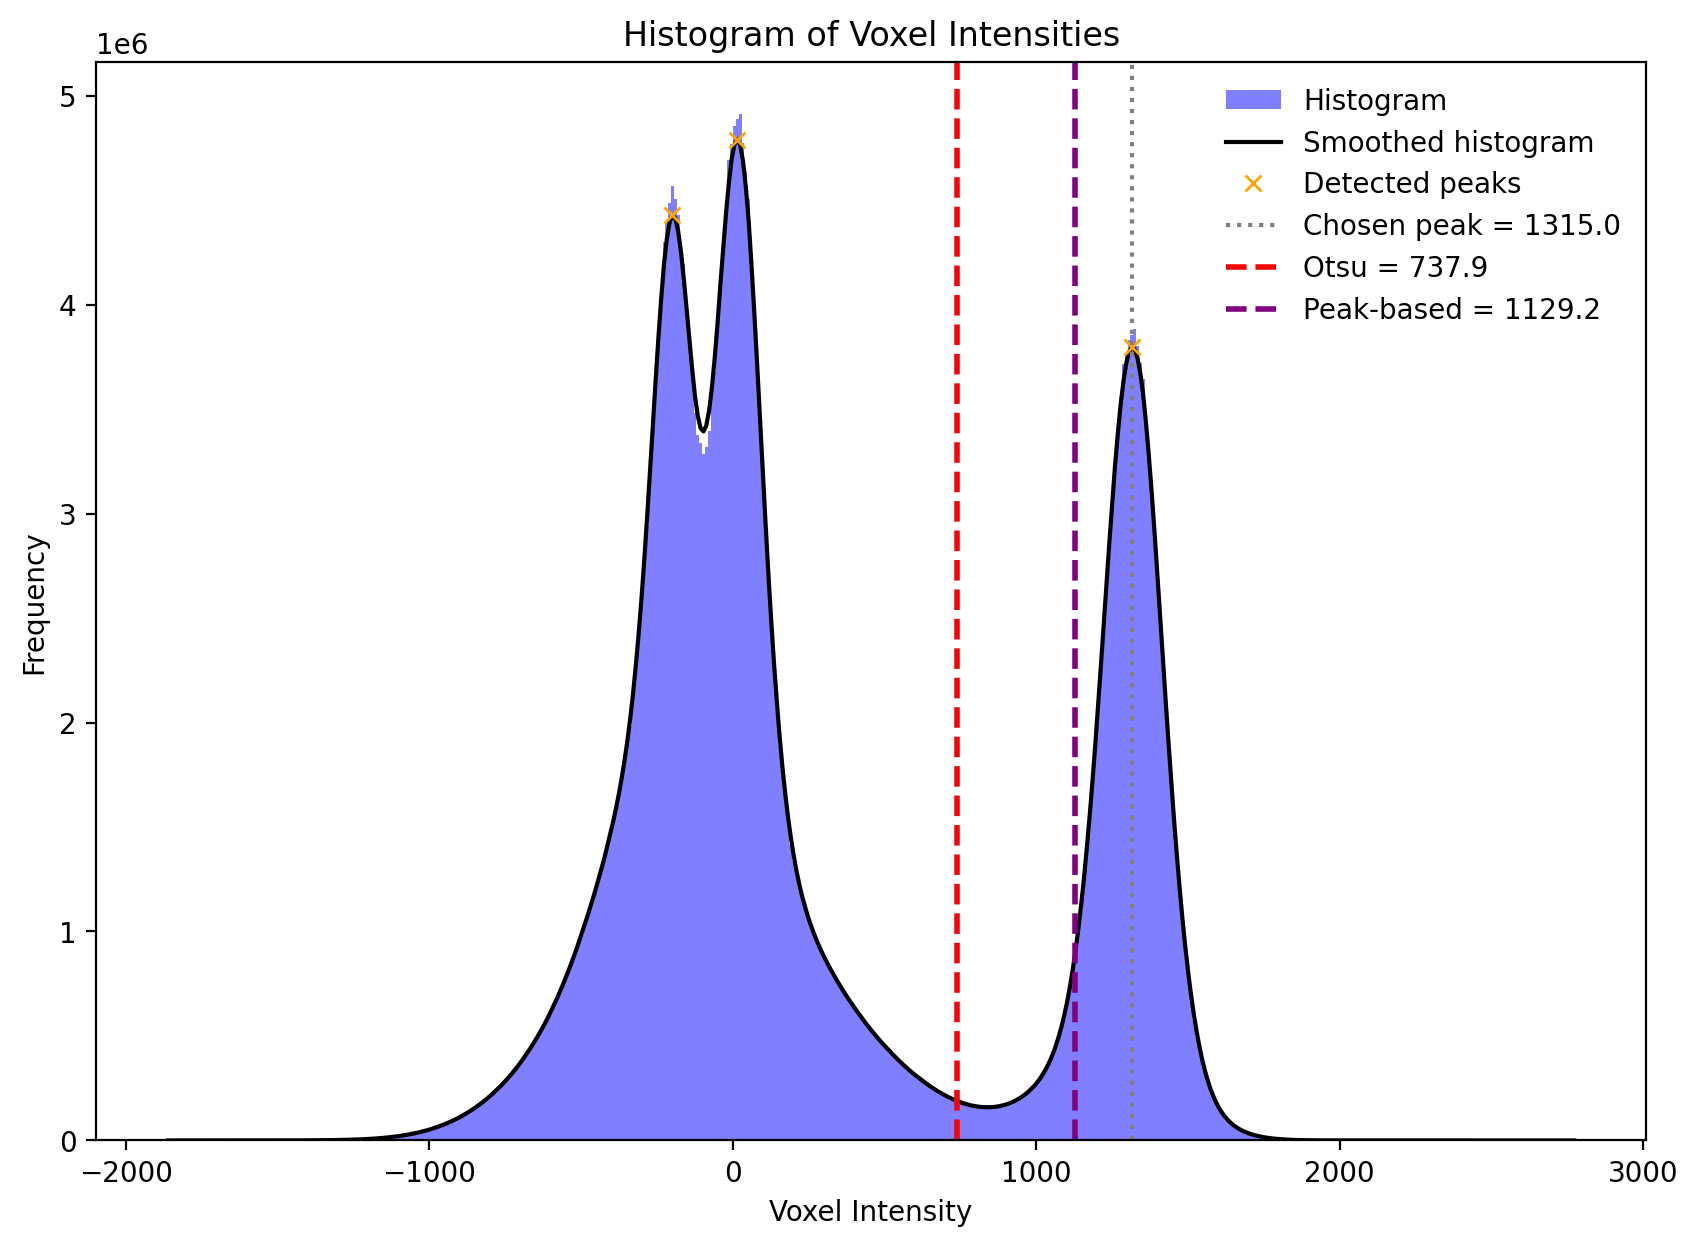

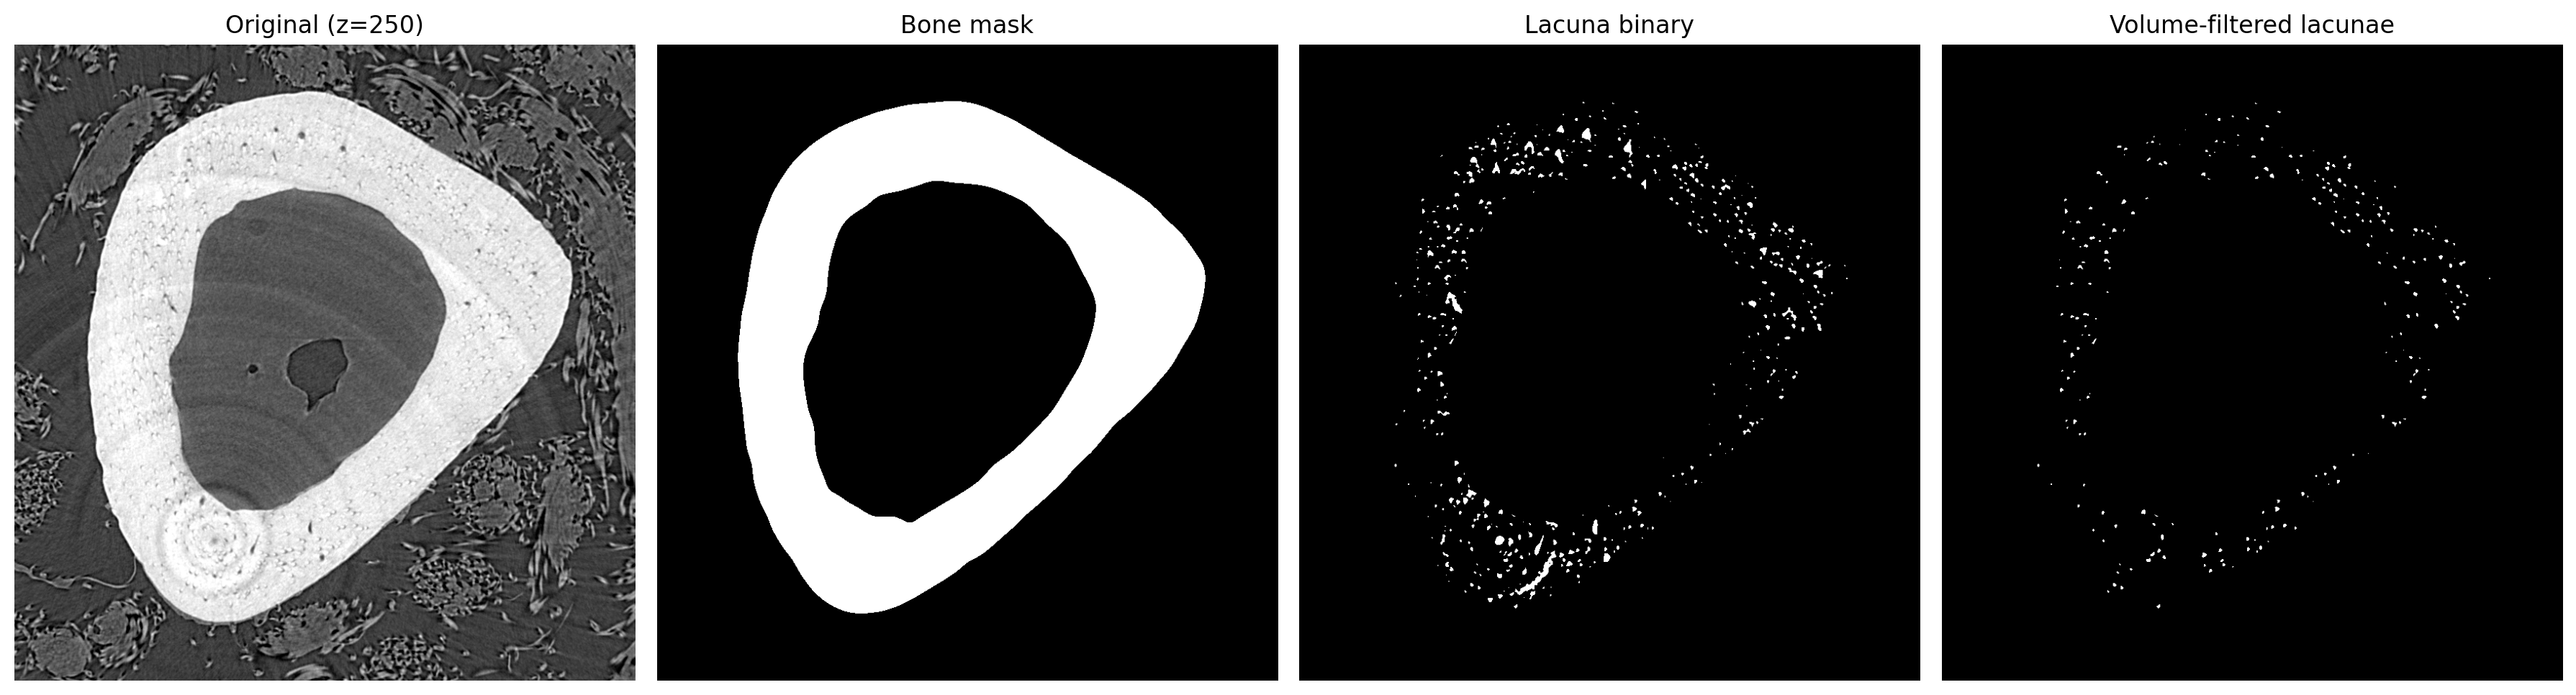

In [10]:
for diagnostic_plot in [output_dir / "thresholds.png", output_dir / "segmentation_diagnostic.png"]:
    if diagnostic_plot.exists():
        display(Image(filename=str(diagnostic_plot)))
    else:
        print(f"Diagnostic plot has not been written yet: {diagnostic_plot}")

---
<a name="dependencies"></a>
## Dependencies

For reproducibility, record the Python version and relevant package versions. The optional `watermark` package provides a compact report when installed.

In [ ]:
try:
    %load_ext watermark
    %watermark
    %watermark --iversions
except ModuleNotFoundError:
    import importlib.metadata
    import platform

    packages = [
        "aimio-py",
        "lacunae-analysis",
        "matplotlib",
        "numpy",
        "pandas",
        "SimpleITK",
    ]
    print(f"Python: {platform.python_version()}")
    for package in packages:
        try:
            version = importlib.metadata.version(package)
        except importlib.metadata.PackageNotFoundError:
            version = "not installed"
        print(f"{package}: {version}")

---
<a name="references"></a>
## References

- `lacunae-analysis` repository: https://github.com/ORMIR-microCT/LacunaeAnalysis
- `aimio-py` package: https://pypi.org/project/aimio-py/
- ORMIR community notebook template: https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb

---
<a name="acknowledgements"></a>
## Acknowledgements

This workflow was prepared for the ORMIR microCT organization and adapted from the original lacunae analysis notebook into a reusable package-guided workflow.

---
<a name="attribution"></a>
Notebook created using the [template](https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb) of the [ORMIR community](https://ormircommunity.github.io/).